# Per-cell SoH trajectories — visual QA

One subplot per cell across CALB / REPT / EVE. No aggregation, no median, no cohort overlay — each cell is inspected on its own for shape sanity before we commit to a training cohort.

**SoH sources**:
- **CALB** — `extract.py::calb_longterm_soh` (batch=1 from Longterm `discharge_cap_ah`, batch=2 from `df_calb_cc_cap.csv`'s `cc_capacity_ah`, both normalised by 72 Ah nameplate). CC-CV protocol seam is baked in transparently.
- **REPT** — `soh/data/canonical/rept.parquet` (already-normalised training-pipeline SoH; known to have per-batch renormalisation artifacts on some cells).
- **EVE** — `soh/data/canonical/eve.parquet` (already-normalised).

**Reference lines in each subplot**:
- Solid horizontal at **SoH = 1.00** (fresh)
- Dotted horizontal at **SoH = 0.80** (EoL)
- Dashed horizontal at **SoH = 0.60** (second-life lower bound)
- For CALB only: dashed vertical at the batch-1|2 seam

**Title colour**:
- Green cell ID → passes SoH_first ∈ [0.60, 1.00] AND fade ≥ −3 pp (monotonic-ish)
- Red cell ID → fails one or both of those


In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
HERE = Path('/home/hj/Desktop/PINNs/Voltaris/Data_Exploration')
sys.path.insert(0, str(HERE))

from extract import calb_longterm_soh

COLOR = {'CALB': '#c94a3c', 'REPT': '#3c7cc9', 'EVE': '#4dab5c'}

# ---- Load all three cohorts' SoH traces ----
def _load_calb():
    return calb_longterm_soh()  # {cell: DataFrame(cycle, soh, batch)}

def _load_parquet(path):
    df = pd.read_parquet(path)
    df['cell'] = df['cell_id'].astype(str).str.zfill(4)
    out = {}
    for c, sub in df.groupby('cell'):
        sub = sub.sort_values('global_cycle').reset_index(drop=True)
        out[c] = sub.rename(columns={'global_cycle': 'cycle'})[['cycle', 'soh']]
    return out

traces = {
    'CALB': _load_calb(),
    'REPT': _load_parquet('/home/hj/Desktop/PINNs/soh/data/canonical/rept.parquet'),
    'EVE':  _load_parquet('/home/hj/Desktop/PINNs/soh/data/canonical/eve.parquet'),
}
for m, t in traces.items():
    print(f'{m}: {len(t)} cells loaded')

CALB: 27 cells loaded
REPT: 26 cells loaded
EVE: 8 cells loaded


In [2]:
def _cell_stats(df):
    s = df['soh'].dropna().values
    if s.size < 3:
        return dict(soh_first=np.nan, soh_last=np.nan, fade_pp=np.nan, n_cy=len(df))
    return dict(
        soh_first=float(np.mean(s[:5])),
        soh_last=float(np.mean(s[-5:])),
        fade_pp=float((np.mean(s[:5]) - np.mean(s[-5:])) * 100),
        n_cy=int(df['cycle'].max()),
    )

def _passes_filter(stats):
    return (0.60 <= stats['soh_first'] <= 1.00) and (stats['fade_pp'] > -3.0)

def _plot_grid(make, ncols=6, height_per_row=2.2):
    cohort = traces[make]
    cells = sorted(cohort.keys())
    ncells = len(cells)
    nrows = int(np.ceil(ncells / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(2.6 * ncols, height_per_row * nrows),
                              sharey=True)
    axes = np.array(axes).ravel()
    color = COLOR[make]
    n_pass = 0

    for i, cell in enumerate(cells):
        ax = axes[i]
        df = cohort[cell]
        stats = _cell_stats(df)
        passes = _passes_filter(stats)
        n_pass += int(passes)

        ax.plot(df['cycle'], df['soh'], color=color, lw=1.1, alpha=0.9)
        # reference lines
        ax.axhline(1.00, color='0.55', ls='-', lw=0.5, alpha=0.6)
        ax.axhline(0.80, color='k',    ls=':', lw=0.6, alpha=0.6)
        ax.axhline(0.60, color='0.35', ls='--', lw=0.6, alpha=0.5)
        # batch seam for CALB
        if make == 'CALB' and 'batch' in df.columns:
            seam = int((df['batch'] == 1).sum())
            if seam > 0:
                ax.axvline(seam + 0.5, color='0.5', ls='--', lw=0.5, alpha=0.55)
        title_color = '#1e8f4e' if passes else '#c94a3c'
        ax.set_title(f'{cell}  n={stats["n_cy"]}\n'
                     f'{stats["soh_first"]:.2f} → {stats["soh_last"]:.2f}   '
                     f'{stats["fade_pp"]:+.1f} pp',
                     fontsize=8, color=title_color)
        ax.set_ylim(0.30, 1.10)
        ax.set_xlim(0, max(int(df['cycle'].max()), 1))
        ax.grid(alpha=0.20)
        ax.tick_params(labelsize=7)

    # bottom-row x label
    for j in range(len(cells), len(axes)):
        axes[j].axis('off')
    for j in range(ncells - ncols, ncells):
        axes[j].set_xlabel('cycle', fontsize=8)
    for j in range(0, ncells, ncols):
        axes[j].set_ylabel('SoH', fontsize=8)

    fig.suptitle(f'{make} — per-cell SoH trajectories '
                 f'(passes filter: {n_pass} / {ncells})',
                 fontsize=12, y=1.005)
    fig.tight_layout()
    plt.show()
    return n_pass, ncells

## CALB batch=2 cohort

27 cells. Loader uses batch=1 Longterm dchg_cap + batch=2 CC-only cap (CC-CV protocol fix). Watch for:

- Reasonable monotonic-ish fade across the 400-cycle span
- Batch seam step less than a few pp (large step = fix didn't work for that cell)
- Any cell whose trajectory crosses the SoH=0.60 lower guide
- Any cell whose trajectory rises visibly (physically impossible)

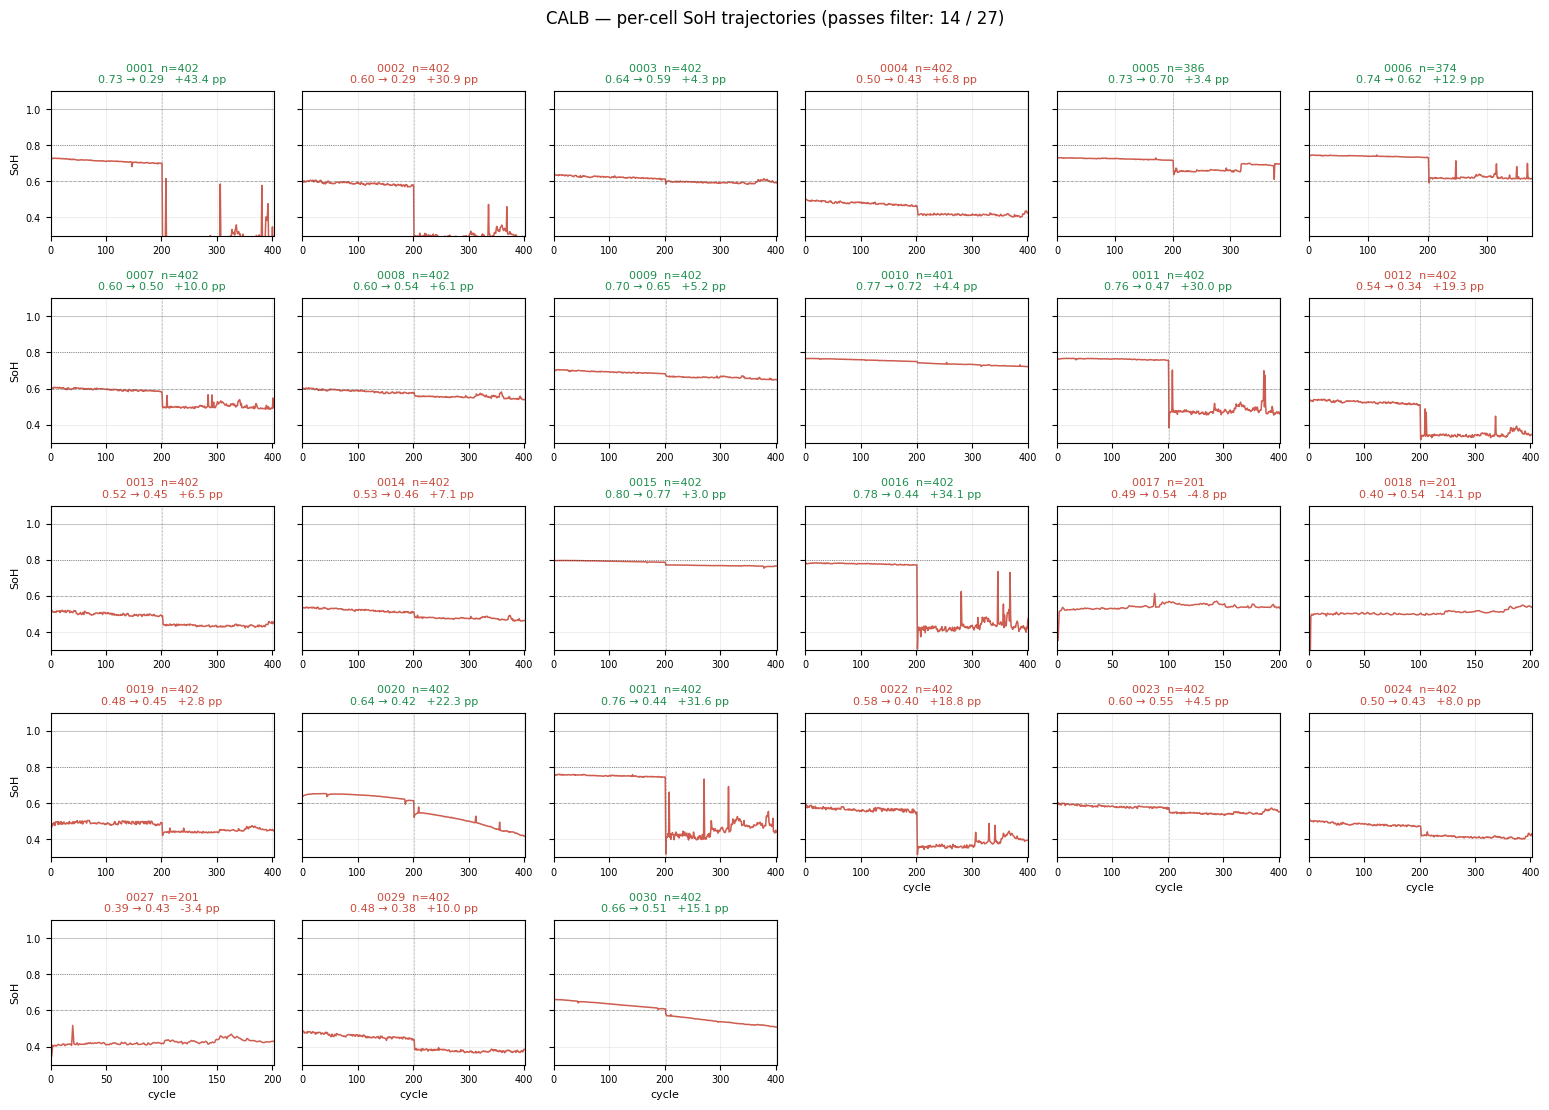

(14, 27)

In [3]:
_plot_grid('CALB', ncols=6, height_per_row=2.2)

## REPT cohort

26 cells. Loader uses `rept.parquet` as-is (no bespoke fix). Expect a bimodal distribution — most cells near 1.00, a family stuck low (0.55–0.65) with what looks like per-batch renormalisation artifacts (SoH going UP over cycling).

Cells with clearly non-monotonic trajectories (rising) should be dropped even if they pass the SoH_first bounds — those are data-pipeline artifacts, not real cells.

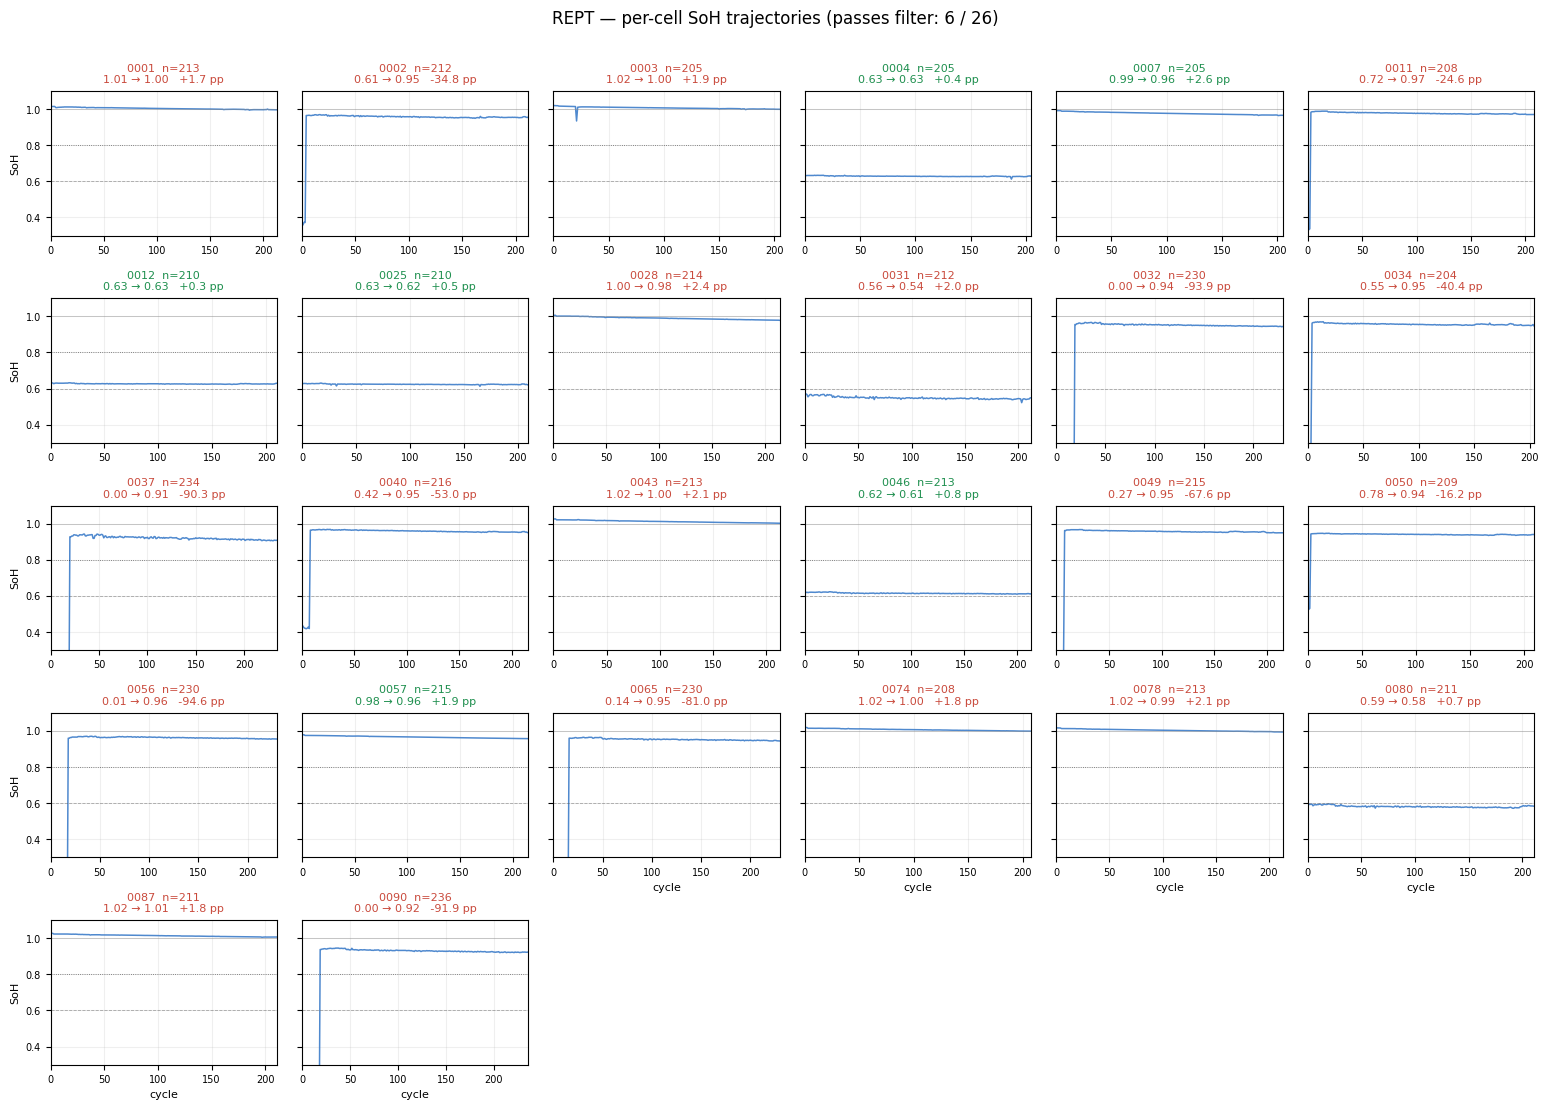

(6, 26)

In [4]:
_plot_grid('REPT', ncols=6, height_per_row=2.2)

## EVE cohort

8 cells. Shortest Longterm (46–150 cycles), so fade should be small everywhere. Watch for any cell whose SoH_first is well below 1.00 (heavily aged — probably shouldn't be treated as fresh) or that shows a clear discontinuity.

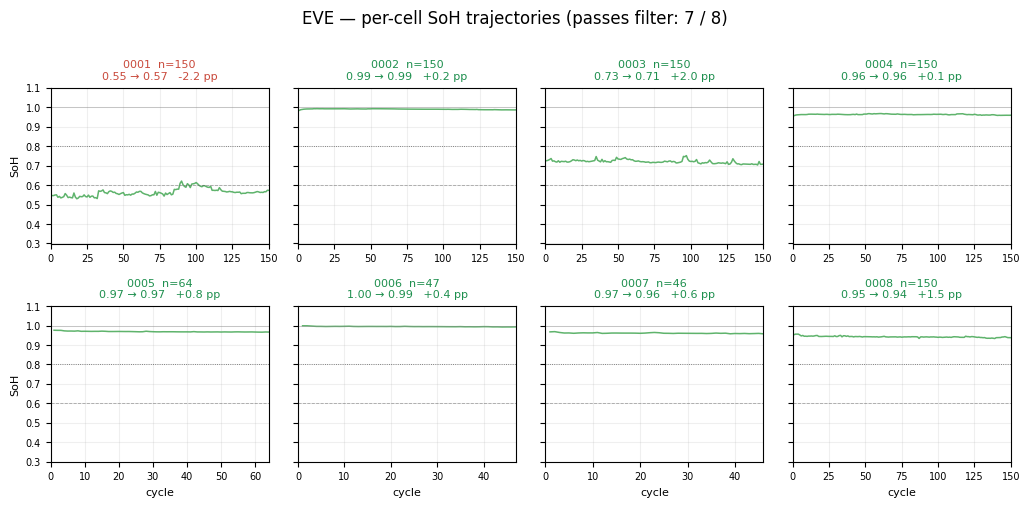

(7, 8)

In [5]:
_plot_grid('EVE', ncols=4, height_per_row=2.5)

## Summary — which cells pass the SoH filter

One row per cell, sorted by make then cell ID. `pass` reflects the same test as the subplot titles (SoH_first ∈ [0.60, 1.00] AND fade > −3 pp).

This is the cohort we'd use as the starting point for Phase 1 calibration. Any cell you visually reject in the panels above should be manually removed before we commit.

In [6]:
rows = []
for make in ['CALB', 'REPT', 'EVE']:
    for cell, df in sorted(traces[make].items()):
        s = _cell_stats(df)
        rows.append(dict(make=make, cell=cell,
                          n_cy=s['n_cy'],
                          soh_first=round(s['soh_first'], 3),
                          soh_last=round(s['soh_last'], 3),
                          fade_pp=round(s['fade_pp'], 2),
                          passes=_passes_filter(s)))
summary = pd.DataFrame(rows)
counts = summary.groupby('make').agg(
    total=('cell', 'count'),
    pass_count=('passes', 'sum'),
).reset_index()
counts['pass_rate'] = (counts['pass_count'] / counts['total']).round(3)
display(Markdown('### Filter pass counts per cohort'))
display(counts)
display(Markdown('### Full per-cell table'))
display(summary)
summary.to_csv(HERE / 'soh_per_cell_summary.csv', index=False)
print(f'Wrote per-cell summary: {HERE / "soh_per_cell_summary.csv"}')

### Filter pass counts per cohort

,make,total,pass_count,pass_rate
0,CALB,27,14,0.519
1,EVE,8,7,0.875
2,REPT,26,6,0.231


### Full per-cell table

,make,cell,n_cy,soh_first,soh_last,fade_pp,passes
0,CALB,0001,402,0.728,0.295,43.38,True
1,CALB,0002,402,0.599,0.291,30.89,False
2,CALB,0003,402,0.636,0.593,4.28,True
3,CALB,0004,402,0.497,0.429,6.79,False
4,CALB,0005,386,0.730,0.696,3.42,True
...,...,...,...,...,...,...,...
56,EVE,0004,150,0.961,0.959,0.13,True
57,EVE,0005,64,0.974,0.967,0.77,True
58,EVE,0006,47,0.997,0.993,0.43,True
59,EVE,0007,46,0.965,0.959,0.61,True


Wrote per-cell summary: /home/hj/Desktop/PINNs/Voltaris/Data_Exploration/soh_per_cell_summary.csv


## CALB — selected training cohort (5 cells)

Cells cycled at **DoD ∈ {0_100, 15_100}**, excluding **0005, 0019, 0020, 0030**, AND with **SoH_first ≥ 0.60** (the second-life floor).

- DoD **0_100** (2 cells): 0010, 0015
- DoD **15_100** (3 cells): 0003, 0008, 0009

Plotly interactive figure — hover on any trace for cell ID / DoD / cycle / SoH.

Reference lines: nominal (1.00, dotted), EoL (0.80, dotted), second-life floor (0.60, dashed). Vertical dashed line at global_cycle 201 marks the batch-1 to batch-2 seam.

In [7]:
import plotly.graph_objects as go

CALB_SELECTED = {
    '0_100':  ['0010', '0015'],
    '15_100': ['0003', '0008', '0009'],
}

# Consistent per-cell colours; DoD grouping conveyed by line style
palette = ['#c94a3c', '#3c7cc9', '#4dab5c', '#c98b3c', '#7a4dab']
dash_by_dod = {'0_100': 'dash', '15_100': 'solid'}

fig = go.Figure()
color_idx = 0
for dod, cells in CALB_SELECTED.items():
    for cid in cells:
        df = traces['CALB'][cid]
        fig.add_trace(go.Scatter(
            x=df['cycle'], y=df['soh'],
            mode='lines',
            name=f'{cid} · {dod}',
            line=dict(color=palette[color_idx % len(palette)],
                      width=2.0, dash=dash_by_dod[dod]),
            hovertemplate=(
                f'<b>cell {cid}</b><br>'
                f'DoD {dod}<br>'
                'cycle %{x}<br>SoH %{y:.3f}<extra></extra>'
            ),
        ))
        color_idx += 1

for y, label, dash in [(1.00, 'nominal', 'dot'),
                        (0.80, 'EoL 0.80', 'dot'),
                        (0.60, 'second-life floor 0.60', 'dash')]:
    fig.add_hline(y=y, line=dict(color='grey', width=0.8, dash=dash),
                  annotation_text=label, annotation_position='right',
                  annotation_font_size=9)

fig.add_vline(x=201.5, line=dict(color='grey', width=0.7, dash='dash'),
              annotation_text='batch 1|2 seam',
              annotation_position='top', annotation_font_size=9)

fig.update_layout(
    title=dict(text='CALB selected training cohort — SoH vs cycle (5 cells, SoH_first ≥ 0.60)',
                x=0.02, xanchor='left', font_size=14),
    xaxis=dict(title='global cycle', gridcolor='rgba(0,0,0,0.08)'),
    yaxis=dict(title='SoH (CC-corrected)', range=[0.55, 1.05],
                gridcolor='rgba(0,0,0,0.08)'),
    legend=dict(orientation='v', x=1.02, y=1.0,
                 title='cell · DoD', font_size=10),
    plot_bgcolor='white',
    width=1000, height=520,
    margin=dict(l=60, r=140, t=60, b=50),
)
fig.show()

## REPT & EVE — noise-based cohort selection

For each REPT and EVE cell we compute a **noise metric**: the standard deviation of the SoH residual after subtracting a rolling median (window = 11, centred). Low noise = smooth trajectory; high noise = jumpy trajectory (per-batch renorm artifact, sensor spikes, etc.).

Filter: `SoH_first ≥ 0.60` AND `fade_pp > −3 pp` (same as CALB filter).

Then rank surviving cells by noise ascending and take the top 5 per make.

In [8]:
def _noise_metric(df, window=11):
    s = df['soh'].dropna().values
    if len(s) < window:
        return np.nan
    smooth = pd.Series(s).rolling(window, center=True, min_periods=3).median().values
    resid = s - smooth
    return float(np.nanstd(resid))

def _cell_summary(make):
    rows = []
    for cell, df in traces[make].items():
        s = _cell_stats(df)
        s['noise_std'] = _noise_metric(df)
        s['cell'] = cell
        rows.append(s)
    out = pd.DataFrame(rows)
    out['passes_soh'] = (out['soh_first'].between(0.60, 1.00)
                         & (out['fade_pp'] > -3.0))
    return out

for make in ['REPT', 'EVE']:
    tbl = _cell_summary(make)
    tbl = tbl.sort_values('noise_std').reset_index(drop=True)
    display(Markdown(f'### {make} — cells ranked by noise (ascending)'))
    display(tbl[['cell', 'n_cy', 'soh_first', 'soh_last', 'fade_pp',
                  'noise_std', 'passes_soh']].round(4))

# Top-5 quietest per make that pass the SoH filter
CHOSEN = {}
for make in ['REPT', 'EVE']:
    tbl = _cell_summary(make).sort_values('noise_std')
    keep = tbl[tbl['passes_soh']].head(5)['cell'].tolist()
    CHOSEN[make] = keep
    display(Markdown(f'**{make} top-5 quietest (passing SoH filter):** `{keep}`'))

### REPT — cells ranked by noise (ascending)

,cell,n_cy,soh_first,soh_last,fade_pp,noise_std,passes_soh
0,0078,213,1.0154,0.9943,2.1123,0.0003,False
1,0057,215,0.9762,0.9571,1.9043,0.0004,True
2,0007,205,0.9904,0.9648,2.5580,0.0004,True
3,0087,211,1.0245,1.0064,1.8065,0.0004,False
4,0074,208,1.0161,0.9985,1.7607,0.0004,False
5,0028,214,1.0026,0.9783,2.4272,0.0005,False
6,0043,213,1.0229,1.0023,2.0587,0.0005,False
7,0001,213,1.0127,0.9959,1.6801,0.0006,False
8,0012,210,0.6300,0.6273,0.2697,0.0007,True
9,0056,230,0.0096,0.9556,-94.5923,0.0008,False


### EVE — cells ranked by noise (ascending)

,cell,n_cy,soh_first,soh_last,fade_pp,noise_std,passes_soh
0,0002,150,0.9890,0.9871,0.1918,0.0005,True
1,0006,47,0.9975,0.9932,0.4286,0.0007,True
2,0005,64,0.9744,0.9667,0.7693,0.0007,True
3,0004,150,0.9608,0.9595,0.1305,0.0008,True
4,0007,46,0.9651,0.9590,0.6130,0.0016,True
5,0008,150,0.9547,0.9396,1.5090,0.0016,True
6,0003,150,0.7292,0.7096,1.9636,0.0059,True
7,0001,150,0.5461,0.5684,-2.2350,0.0066,False


**REPT top-5 quietest (passing SoH filter):** `['0057', '0007', '0012', '0046', '0004']`

**EVE top-5 quietest (passing SoH filter):** `['0002', '0006', '0005', '0004', '0007']`

In [9]:
# Plotly overlay of the selected quiet cells, per make
palette = ['#c94a3c', '#3c7cc9', '#4dab5c', '#c98b3c', '#7a4dab']

for make in ['REPT', 'EVE']:
    fig = go.Figure()
    for i, cid in enumerate(CHOSEN[make]):
        df = traces[make][cid]
        fig.add_trace(go.Scatter(
            x=df['cycle'], y=df['soh'],
            mode='lines', name=f'{cid}',
            line=dict(color=palette[i % len(palette)], width=2.0),
            hovertemplate=(
                f'<b>cell {cid}</b><br>cycle %{{x}}<br>SoH %{{y:.3f}}'
                '<extra></extra>'
            ),
        ))
    for y, label, dash in [(1.00, 'nominal', 'dot'),
                            (0.80, 'EoL 0.80', 'dot'),
                            (0.60, 'floor 0.60', 'dash')]:
        fig.add_hline(y=y, line=dict(color='grey', width=0.8, dash=dash),
                       annotation_text=label, annotation_position='right',
                       annotation_font_size=9)
    fig.update_layout(
        title=dict(text=f'{make} — top-5 quietest cells (SoH_first ≥ 0.60)',
                    x=0.02, xanchor='left', font_size=13),
        xaxis=dict(title='cycle', gridcolor='rgba(0,0,0,0.08)'),
        yaxis=dict(title='SoH', range=[0.30, 1.05],
                    gridcolor='rgba(0,0,0,0.08)'),
        legend=dict(orientation='v', x=1.02, y=1.0, title='cell', font_size=10),
        plot_bgcolor='white',
        width=1000, height=440,
        margin=dict(l=60, r=140, t=50, b=40),
    )
    fig.show()

## Final locked training cohort (13 cells across 3 makes)

**Selection principle**: prefer cells with meaningful fade signal over the flattest trajectories, since the DE fit needs signal to constrain SEI kinetics. Light rolling-median smoothing (window=7) will suppress single-cycle spikes without erasing the fade signal.

| Make | Cells | Rationale |
|---|---|---|
| **CALB** (5) | 0003, 0008, 0009, 0010, 0015 | DoD ∈ {0_100, 15_100}, SoH_first ≥ 0.60 |
| **EVE** (3)  | 0002, 0003, 0004, 0008 | 150-cy cells only (shorter ones drop out) |
| **REPT** (5) | 0004, 0007, 0012, 0046, 0057 | best 5 of 6 SoH-filter survivors |

Plotly overlay below shows raw (thin dashed) and rolling-median-smoothed (bold solid) trajectories for the EVE + REPT picks so we can verify smoothing preserves the fade shape.

In [10]:
FINAL_COHORT = {
    'CALB': ['0003', '0008', '0009', '0010', '0015'],
    'EVE':  ['0002', '0004', '0008'],
    'REPT': ['0004', '0007', '0012', '0046', '0057'],
}

SMOOTH_WINDOW = 7  # cycles; small enough to preserve fade shape

def _smoothed(df, window=SMOOTH_WINDOW):
    return pd.Series(df['soh'].values).rolling(window, center=True, min_periods=3).median().values

palette = ['#c94a3c', '#3c7cc9', '#4dab5c', '#c98b3c', '#7a4dab', '#3cabc9']

for make in ['EVE', 'REPT']:
    fig = go.Figure()
    for i, cid in enumerate(FINAL_COHORT[make]):
        df = traces[make][cid]
        col = palette[i % len(palette)]
        # raw (thin dashed)
        fig.add_trace(go.Scatter(
            x=df['cycle'], y=df['soh'], mode='lines',
            name=f'{cid} raw', line=dict(color=col, width=0.9, dash='dot'),
            hovertemplate=(f'<b>{cid} raw</b><br>cycle %{{x}}<br>'
                            'SoH %{y:.3f}<extra></extra>'),
            legendgroup=cid, showlegend=False,
        ))
        # smoothed (bold solid)
        fig.add_trace(go.Scatter(
            x=df['cycle'], y=_smoothed(df), mode='lines',
            name=f'{cid} (smoothed)', line=dict(color=col, width=2.2),
            hovertemplate=(f'<b>{cid} smoothed</b><br>cycle %{{x}}<br>'
                            'SoH %{y:.3f}<extra></extra>'),
            legendgroup=cid,
        ))
    for y, label, dash in [(1.00, 'nominal', 'dot'),
                            (0.80, 'EoL 0.80', 'dot'),
                            (0.60, 'floor 0.60', 'dash')]:
        fig.add_hline(y=y, line=dict(color='grey', width=0.8, dash=dash),
                       annotation_text=label, annotation_position='right',
                       annotation_font_size=9)
    fig.update_layout(
        title=dict(text=f'{make} training cohort — raw vs rolling-median (window={SMOOTH_WINDOW})',
                    x=0.02, xanchor='left', font_size=13),
        xaxis=dict(title='cycle', gridcolor='rgba(0,0,0,0.08)'),
        yaxis=dict(title='SoH', range=[0.55, 1.05],
                    gridcolor='rgba(0,0,0,0.08)'),
        legend=dict(orientation='v', x=1.02, y=1.0, title='cell', font_size=10),
        plot_bgcolor='white',
        width=1000, height=440,
        margin=dict(l=60, r=140, t=50, b=40),
    )
    fig.show()

# Persist cohort selection to a machine-readable file
import yaml as _yaml
COHORT_YAML = HERE / 'training_cohort.yaml'
manifest = {
    'version': 2,
    'generated_by': 'soh_trajectories_by_cell.ipynb',
    'selection_criteria': {
        'CALB': {'DoD': ['0_100', '15_100'],
                  'SoH_first_min': 0.60,
                  'excluded_cells': ['0005', '0019', '0020', '0030']},
        'EVE':  {'SoH_first_min': 0.60, 'n_cycles_min': 150,
                  'excluded_cells': ['0003'],
                  'exclusion_reason': ('EVE 0003 has no GITT test in Athena; '
                                         'drops EVE cohort from 4 to 3 cells'),
                  'note': 'only cells with 150-cy trajectories qualify for DE fit'},
        'REPT': {'SoH_first_min': 0.60,
                  'monotone_min': -3.0,
                  'note': 'noise-ranked, top-5 with rolling-median smoothability'},
    },
    'test_coverage': {
        'required_tests': ['OCV_SOC', 'GITT', 'HPPC', 'RPT', 'Longterm'],
        'optional_tests': ['DCIR', 'SelfDischarge'],
        'required_note': ('All 13 cohort cells have 100% coverage on required tests. '
                           'These are the minimum inputs for Phase 1 BOL identification '
                           '(OCV + GITT + HPPC + RPT) and Phase 2 DE fit target (Longterm).'),
        'optional_note': ('DCIR excluded due to variable SoC-sampling protocol across '
                           'batches (HPPC R0 used as the resistance signal instead). '
                           'SelfDischarge is only partially covered — 8 of 13 cohort '
                           'cells have it (2 CALB + 1 EVE + 5 REPT); the missing 5 cells '
                           '(CALB 0008/0009/0010, EVE 0002/0004) were not tested at the '
                           'lab stage, so nothing to pull. SelfDischarge scalars are '
                           'used only in the diagnostic correlation notebook, never as '
                           'a cell-selection gate.'),
    },
    'smoothing': {'method': 'rolling_median', 'window': SMOOTH_WINDOW},
    'cohort': FINAL_COHORT,
    'n_cells_total': sum(len(v) for v in FINAL_COHORT.values()),
}
COHORT_YAML.write_text(_yaml.safe_dump(manifest, sort_keys=False))
print(f'Wrote canonical cohort manifest: {COHORT_YAML}')
print(f'Total cells: {manifest["n_cells_total"]}')

Wrote canonical cohort manifest: /home/hj/Desktop/PINNs/Voltaris/Data_Exploration/training_cohort.yaml
Total cells: 13


## All 13 cohort cells in one plot, coloured by make

Smoothed trajectories only (rolling median, window = 7). Colour by make; hover shows cell + make + cycle + SoH.

In [11]:
MAKE_COLOR_MAP = {'CALB': '#c94a3c', 'EVE': '#4dab5c', 'REPT': '#3c7cc9'}

fig = go.Figure()
for make in ['CALB', 'EVE', 'REPT']:
    color = MAKE_COLOR_MAP[make]
    first_in_group = True
    for cid in FINAL_COHORT[make]:
        df = traces[make][cid]
        y_smooth = _smoothed(df, window=SMOOTH_WINDOW)
        fig.add_trace(go.Scatter(
            x=df['cycle'], y=y_smooth,
            mode='lines',
            name=make if first_in_group else None,
            legendgroup=make,
            showlegend=first_in_group,
            line=dict(color=color, width=1.8),
            opacity=0.85,
            hovertemplate=(
                f'<b>{make} · cell {cid}</b><br>'
                'cycle %{x}<br>SoH %{y:.3f}<extra></extra>'
            ),
        ))
        first_in_group = False

for y, label, dash in [(1.00, 'nominal', 'dot'),
                        (0.80, 'EoL 0.80', 'dot'),
                        (0.60, 'floor 0.60', 'dash')]:
    fig.add_hline(y=y, line=dict(color='grey', width=0.8, dash=dash),
                   annotation_text=label, annotation_position='right',
                   annotation_font_size=9)

fig.update_layout(
    title=dict(text=f'Full training cohort — SoH vs cycle (smoothed, w={SMOOTH_WINDOW})  ·  '
                    f'13 cells: 5 CALB + 3 EVE + 5 REPT',
                x=0.02, xanchor='left', font_size=13),
    xaxis=dict(title='cycle', gridcolor='rgba(0,0,0,0.08)'),
    yaxis=dict(title='SoH', range=[0.55, 1.05],
                gridcolor='rgba(0,0,0,0.08)'),
    legend=dict(orientation='v', x=1.02, y=1.0, title='make', font_size=11),
    plot_bgcolor='white',
    width=1050, height=560,
    margin=dict(l=60, r=140, t=60, b=50),
)
fig.show()

## Starting-SoH distribution across the 13 chosen cells

Where does each cell sit on the "how much prior aging" axis? For DE fits to identify distinct θ values across the corpus, we want spread — not a cluster in one narrow band.

In [12]:
soh_first_rows = []
for make, cells in FINAL_COHORT.items():
    for cid in cells:
        s = traces[make][cid]['soh'].dropna().values
        if s.size >= 5:
            soh_first_rows.append({'make': make, 'cell': cid,
                                    'soh_first': float(np.mean(s[:5])),
                                    'soh_last':  float(np.mean(s[-5:])),
                                    'fade_pp':   float((np.mean(s[:5]) - np.mean(s[-5:])) * 100)})
sf = pd.DataFrame(soh_first_rows).sort_values(['make','soh_first'])

# Strip plot: one row per make, dots at each cell's SoH_first
fig = go.Figure()
y_positions = {'CALB': 0, 'EVE': 1, 'REPT': 2}
for _, row in sf.iterrows():
    m = row['make']
    y_jitter = y_positions[m] + np.random.default_rng(int(row['cell'])).uniform(-0.15, 0.15)
    fig.add_trace(go.Scatter(
        x=[row['soh_first']], y=[y_jitter],
        mode='markers+text',
        marker=dict(size=14, color=MAKE_COLOR_MAP[m],
                     line=dict(color='white', width=1.5)),
        text=[row['cell']], textposition='top center', textfont=dict(size=10),
        showlegend=False,
        hovertemplate=(
            f'<b>{m} · cell {row["cell"]}</b><br>'
            f'SoH_first: {row["soh_first"]:.3f}<br>'
            f'SoH_last:  {row["soh_last"]:.3f}<br>'
            f'fade: {row["fade_pp"]:+.1f} pp<extra></extra>'
        ),
    ))

# Reference: SoH filter bounds
fig.add_vline(x=0.60, line=dict(color='grey', width=0.8, dash='dash'),
              annotation_text='floor 0.60', annotation_position='top right',
              annotation_font_size=9)
fig.add_vline(x=1.00, line=dict(color='grey', width=0.5, dash='dot'),
              annotation_text='nominal', annotation_position='top right',
              annotation_font_size=9)

fig.update_layout(
    title=dict(text='Starting SoH per cell — 13-cell training cohort',
                x=0.02, xanchor='left', font_size=13),
    xaxis=dict(title='SoH_first', range=[0.55, 1.05],
                gridcolor='rgba(0,0,0,0.08)'),
    yaxis=dict(title='make',
                tickmode='array',
                tickvals=list(y_positions.values()),
                ticktext=list(y_positions.keys()),
                range=[-0.6, 2.6],
                gridcolor='rgba(0,0,0,0.08)'),
    plot_bgcolor='white',
    width=950, height=380,
    margin=dict(l=70, r=40, t=50, b=50),
)
fig.show()

# Summary stats
display(Markdown('### SoH_first summary'))
display(sf[['make','cell','soh_first','soh_last','fade_pp']].round(3))
display(Markdown('### Per-make range'))
display(sf.groupby('make').agg(
    n=('cell','count'),
    min_soh_first=('soh_first','min'),
    max_soh_first=('soh_first','max'),
    span=('soh_first', lambda x: x.max()-x.min()),
    median=('soh_first','median'),
).round(3))

### SoH_first summary

,make,cell,soh_first,soh_last,fade_pp
1,CALB,0008,0.600,0.539,6.108
0,CALB,0003,0.636,0.593,4.282
2,CALB,0009,0.702,0.650,5.202
3,CALB,0010,0.766,0.722,4.424
4,CALB,0015,0.795,0.765,2.974
7,EVE,0008,0.955,0.940,1.509
6,EVE,0004,0.961,0.959,0.130
5,EVE,0002,0.989,0.987,0.192
11,REPT,0046,0.620,0.612,0.762
10,REPT,0012,0.630,0.627,0.270


### Per-make range

,n,min_soh_first,max_soh_first,span,median
make,,,,,
CALB,5,0.600,0.795,0.195,0.702
EVE,3,0.955,0.989,0.034,0.961
REPT,5,0.620,0.990,0.371,0.632


## Cohort characterisation vs SoH_first — correlation check

For each of the 13 chosen cells, pair the SoH_first (from the CC-CV corrected Longterm loader for CALB, from the training-pipeline parquet for REPT/EVE) with each characterisation scalar.

**Two sources per scalar**:
- **PRE**: pre-computed value from `characterization_results.csv` (`pyspark-incremental-1.0` processor)
- **RAW**: our own `extract.py` computation from raw `detail` CSVs

**Scalars checked**:

| Scalar | Expected r vs SoH_first | Notes |
|---|---|---|
| Q_rpt / nameplate | strong + (they're both capacity) | |
| HPPC R0 median (mΩ) | negative (SEI grows → R rises) | HPPC uses consistent 10-90% SoC pulses across cells |
| GITT tau_diff median (s) | negative (SEI thickens → slower Li diffusion) | |
| Self-discharge dSoC/day | negative (aged cells self-discharge faster) | **optional** — only 8 of 13 cohort cells have this test (2 CALB + 1 EVE + 5 REPT); shown as diagnostic only |
| OCV V_plateau (V) | ~zero (LFP topology is aging-invariant) | control |

> **Note on SelfDischarge**: not a Phase 1 requirement. The scalar is computed where available but never gates cell inclusion. See `training_cohort.yaml → test_coverage.optional_note` for the missing-cell details.


**DCIR intentionally excluded** — batch-to-batch protocol variance (some batches sample DCIR at {20%, 50%, 90%}, others at 2 SoCs, some at 1 SoC only) makes a single R_dc scalar not comparable across cells. HPPC R0 is used instead since its 10-90% pulse ladder is consistent across all our cohort cells.

If PRE and RAW disagree materially for a scalar, RAW is preferred (we know exactly what our extraction is doing).

In [13]:
import ast
from scipy import stats as sstats

NAMEPLATE = {'CALB': 72.0, 'REPT': 150.0, 'EVE': 105.0}
PAIR_BATCH = {'CALB': 2, 'REPT': 1, 'EVE': 1}

# ---- (a) PRE — from characterization_results.csv ----
pre = pd.read_csv('/home/hj/Desktop/PINNs/characterization_results.csv')
pre = pre[pre.make.isin(FINAL_COHORT.keys())].copy()
pre['cell']  = pre['cell'].astype(str).str.zfill(4)
pre['batch'] = pre['batch'].astype(int)
pre = pre[pre.apply(lambda r: r['batch'] == PAIR_BATCH[r['make']], axis=1)]
pre = pre[pre.apply(lambda r: r['cell'] in FINAL_COHORT[r['make']], axis=1)].copy()

def _parse(x):
    if isinstance(x, float) and np.isnan(x): return None
    if isinstance(x, str):
        try: return np.array(ast.literal_eval(x), dtype=float)
        except: return None
    return x

for c in ['ocv_soc_grid', 'v_oc_curve', 'r0_dchg_curve', 'tau_diff_curve']:
    pre[c] = pre[c].apply(_parse)

def _median(a):
    if isinstance(a, np.ndarray) and a.size > 0:
        v = a[np.isfinite(a)]
        return float(np.median(v)) if v.size else np.nan
    return np.nan

def _vplat(row):
    g = row['ocv_soc_grid']; v = row['v_oc_curve']
    if not (isinstance(g, np.ndarray) and isinstance(v, np.ndarray) and g.size > 3):
        return np.nan
    order = np.argsort(g); g = g[order]; v = v[order]
    return float(np.interp(0.5, g, v))

pre['nameplate']         = pre['make'].map(NAMEPLATE)
pre['q_over_nameplate']  = pre['q_rpt_ah'] / pre['nameplate']
pre['r0_median']         = pre['r0_dchg_curve'].apply(_median)
pre['tau_median']        = pre['tau_diff_curve'].apply(_median)
pre['v_plat']            = pre.apply(_vplat, axis=1)
pre['self_disch']        = pre['self_disch_dsoc_per_day']

# ---- (b) RAW — from extract.py's characterization_scalars.csv ----
raw_path = HERE / 'characterization_scalars.csv'
if raw_path.exists():
    raw = pd.read_csv(raw_path)
    raw['cell_id'] = raw['cell_id'].astype(str).str.zfill(4)
    raw = raw[raw.apply(lambda r: r['make'] in FINAL_COHORT and r['cell_id'] in FINAL_COHORT[r['make']], axis=1)].copy()
    raw['nameplate']         = raw['make'].map(NAMEPLATE)
    raw['q_over_nameplate']  = raw['capacity_Ah'] / raw['nameplate']
    raw['r0_median']         = raw['HPPC_R0_mOhm']
    raw['tau_median']        = raw.get('GITT_tau_diff_s', np.nan)
    raw['v_plat']            = raw['V_plateau']
    raw['self_disch']        = raw.get('self_disch_dsoc_per_day', np.nan)
    raw = raw.rename(columns={'cell_id': 'cell'})
else:
    raw = pd.DataFrame(columns=['make','cell','q_over_nameplate','r0_median',
                                   'tau_median','v_plat','self_disch'])
    print('extract.py scalars CSV missing; RAW column will be blank.')

# ---- Attach SoH_first (paired) ----
soh_first_lookup = {(r['make'], r['cell']): r['soh_first'] for _, r in sf.iterrows()}
pre['soh_first'] = pre.apply(lambda r: soh_first_lookup.get((r['make'], r['cell']), np.nan), axis=1)
raw['soh_first'] = raw.apply(lambda r: soh_first_lookup.get((r['make'], r['cell']), np.nan), axis=1)

# ---- Scatter plot per (source, scalar, make) ----
from plotly.subplots import make_subplots

SCALARS = [
    ('q_over_nameplate', 'Q_rpt / nameplate',   'positive'),
    ('r0_median',        'HPPC R0 median (mΩ)', 'negative'),
    ('tau_median',       'GITT tau median (s)', 'negative'),
    ('self_disch',       'Self-disch dSoC/day', 'negative'),
    ('v_plat',           'OCV V_plateau (V)',   '~zero (control)'),
]

for source_name, source_df in [('PRE (pyspark-incremental-1.0)', pre),
                                 ('RAW (extract.py)', raw)]:
    fig = make_subplots(rows=len(SCALARS), cols=3,
                        subplot_titles=[
                            f'{make} · {label}'
                            for _, label, _ in SCALARS
                            for make in ['CALB','REPT','EVE']],
                        vertical_spacing=0.06, horizontal_spacing=0.08)
    for i, (col, label, expect) in enumerate(SCALARS):
        for j, make in enumerate(['CALB', 'REPT', 'EVE']):
            sub = source_df[(source_df['make']==make)
                             & source_df['soh_first'].notna()
                             & source_df[col].notna()].copy()
            if len(sub) < 2:
                continue
            fig.add_trace(go.Scatter(
                x=sub['soh_first'], y=sub[col], mode='markers+text',
                marker=dict(size=11, color=MAKE_COLOR_MAP[make],
                             line=dict(color='white', width=1.2)),
                text=sub['cell'], textposition='top center', textfont_size=9,
                showlegend=False,
                hovertemplate=(
                    f'<b>{make} · %{{text}}</b><br>'
                    f'SoH_first %{{x:.3f}}<br>'
                    f'{label} %{{y:.4f}}<extra></extra>'
                ),
            ), row=i+1, col=j+1)
            # linear fit + r
            if len(sub) >= 3:
                r, p = sstats.pearsonr(sub['soh_first'], sub[col])
                s, itc = np.polyfit(sub['soh_first'], sub[col], 1)
                xx = np.linspace(sub['soh_first'].min(), sub['soh_first'].max(), 20)
                fig.add_trace(go.Scatter(
                    x=xx, y=s*xx + itc, mode='lines',
                    line=dict(color='rgba(80,80,80,0.6)', width=1.2, dash='dash'),
                    showlegend=False, hoverinfo='skip',
                ), row=i+1, col=j+1)
                # r label — put in annotation
                fig.layout.annotations[i*3 + j].update(
                    text=f'{make} · {label}   r={r:+.2f} (n={len(sub)})',
                    font_size=9,
                )

    fig.update_layout(
        title=dict(text=f'{source_name} — SoH_first vs characterisation scalars '
                        f'(13-cell cohort)',
                    x=0.02, font_size=13),
        height=180*len(SCALARS)+80, width=1100,
        plot_bgcolor='white',
        margin=dict(l=50, r=30, t=60, b=40),
    )
    for i in range(len(SCALARS)):
        for j in range(3):
            fig.update_xaxes(gridcolor='rgba(0,0,0,0.08)', row=i+1, col=j+1)
            fig.update_yaxes(gridcolor='rgba(0,0,0,0.08)', row=i+1, col=j+1)
    fig.update_xaxes(title_text='SoH_first', row=len(SCALARS), col=1)
    fig.update_xaxes(title_text='SoH_first', row=len(SCALARS), col=2)
    fig.update_xaxes(title_text='SoH_first', row=len(SCALARS), col=3)
    fig.show()

# ---- Compact side-by-side r matrix ----
def _r_matrix(source_df, tag):
    rows = []
    for col, label, expect in SCALARS:
        row = {'scalar': label, 'expected': expect}
        for make in ['CALB','REPT','EVE']:
            sub = source_df[(source_df['make']==make)
                              & source_df['soh_first'].notna()
                              & source_df[col].notna()]
            if len(sub) >= 3:
                r, _ = sstats.pearsonr(sub['soh_first'], sub[col])
                row[f'{make} (n={len(sub)})'] = f'{r:+.2f}'
            else:
                row[f'{make} (n={len(sub)})'] = f'n<{3}'
        rows.append(row)
    df = pd.DataFrame(rows)
    display(Markdown(f'### Correlation r matrix — **{tag}**'))
    display(df)

_r_matrix(pre, 'PRE (pyspark-incremental-1.0)')
_r_matrix(raw, 'RAW (extract.py)')

### Correlation r matrix — **PRE (pyspark-incremental-1.0)**

,scalar,expected,CALB (n=5),REPT (n=5),EVE (n=3),CALB (n=2),EVE (n=1)
0,Q_rpt / nameplate,positive,+0.26,-0.79,+0.80,NaN,NaN
1,HPPC R0 median (mΩ),negative,-0.15,+0.65,+0.10,NaN,NaN
2,GITT tau median (s),negative,+0.02,-0.89,-0.61,NaN,NaN
3,Self-disch dSoC/day,negative,NaN,+0.75,NaN,n<3,n<3
4,OCV V_plateau (V),~zero (control),+0.62,-0.98,-0.16,NaN,NaN


### Correlation r matrix — **RAW (extract.py)**

,scalar,expected,CALB (n=5),REPT (n=5),EVE (n=3),CALB (n=2),EVE (n=1)
0,Q_rpt / nameplate,positive,+0.26,-0.79,+0.81,NaN,NaN
1,HPPC R0 median (mΩ),negative,-0.25,+0.83,+0.30,NaN,NaN
2,GITT tau median (s),negative,-0.25,-0.88,-0.51,NaN,NaN
3,Self-disch dSoC/day,negative,NaN,+0.83,NaN,n<3,n<3
4,OCV V_plateau (V),~zero (control),+0.62,-0.97,-0.17,NaN,NaN
